In [1]:
import numpy as np
import os, pickle, itertools

import jax
import jax.numpy as jnp
import jax.nn as jnn
import equinox as eqx
import optax
from tqdm import tqdm
import matplotlib.pyplot as plt

from cymetric.pointgen.pointgen_mathematica import PointGeneratorMathematica
from cymetric.jax.models.models import PhiFSModel
from cymetric.jax.models.helper import train_model
from cymetric.jax.models.helper import prepare_basis as jax_prepare_basis
from cymetric.jax.models.callbacks import SigmaCallback

/opt/homebrew/Cellar/python@3.14/3.14.1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/importlib/__init__.py:88: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _bootstrap._gcd_import(name[level:], package, level)


In [2]:
key = jax.random.PRNGKey(42)

psi0 = 2.0
psi1 = 1.0
kmoduli = np.array([1., 1., 1., 1.])   # SUSY locus t1=t2=t3=t4=1
ambient = np.array([1, 1, 1, 1])
alpha   = [1., 0., 1., 0., 0.]
n_cy_pts = 500000
dirname = 'points_TQ_500k'

# Line bundle charge vectors (columns of V matrix, eq. 6.1.10)
k_e2  = np.array([-1., -3.,  2.,  2.])   # L_2
k_e5  = np.array([ 1.,  1.,  0., -2.])   # L_5
k_neg = -(k_e2 + k_e5)                    # L_{-e2-e5}
hym_charges = [k_e2, k_e5, k_neg]
hym_names   = ['e2', 'e5', 'neg']

combinations = list(itertools.product([0, 1], repeat=4))

In [3]:
# Defining polynomial

_mons, _cfs = [], []
for c in combinations:
    _mons.append([2*(1-c[0]), 2*c[0], 2*(1-c[1]), 2*c[1],
                  2*(1-c[2]), 2*c[2], 2*(1-c[3]), 2*c[3]])
    _cfs.append(1. if sum(c) % 2 == 0 else psi0)
_mons.append([1, 1, 1, 1, 1, 1, 1, 1])
_cfs.append(psi1)
monomials    = np.array(_mons, dtype=np.int64)
coefficients = np.array(_cfs)

In [4]:
pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)

basis_path = os.path.join(dirname, 'basis.pickle')
if not os.path.exists(basis_path):
    print(f"Generating {n_cy_pts} CY points ...")
    kappa = pg.prepare_dataset(n_cy_pts, dirname)
    pg.prepare_basis(dirname, kappa)
    print(f"Done. kappa = {kappa:.6f}")
else:
    print(f"Found existing dataset at '{dirname}/'")

with open(basis_path, 'rb') as f:
    BASIS_raw = pickle.load(f)
BASIS = jax_prepare_basis(BASIS_raw)

data = np.load(os.path.join(dirname, 'dataset.npz'))

X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
print(f"X_train: {data['X_train'].shape}  y_train: {data['y_train'].shape}")
print(f"X_val:   {data['X_val'].shape}    y_val:   {data['y_val'].shape}")

Found existing dataset at 'points_TQ_500k/'
X_train: (450000, 16)  y_train: (450000, 2)
X_val:   (50000, 16)    y_val:   (50000, 2)


In [5]:
# Projective input features (globally defined on (P^1)^4)
def kappa_features(z):
    xR = z[:8];  xI = z[8:]
    mag2      = xR**2 + xI**2
    pair_mag2 = mag2.reshape(4, 2).sum(axis=1)
    kap       = jnp.sqrt(jnp.repeat(pair_mag2, 2))
    xR = xR / kap;  xI = xI / kap
    a = jnp.array([0, 2, 4, 6]);  b = jnp.array([1, 3, 5, 7])
    feats = jnp.stack([
        xR[a]*xR[b] + xI[a]*xI[b],
        xR[a]*xI[b] - xI[a]*xR[b],
        xR[a]**2   + xI[a]**2,
        xR[b]**2   + xI[b]**2,
    ], axis=1)
    return feats.reshape(-1)

# --- Γ=Z2xZ2 orbit maps + OUTPUT-averaging wrapper ------------------------------
# β (HYM) and φ (CY metric) are INVARIANT scalars.  Impose it at the OUTPUT level:
# f_sym(x) = (1/|G|) Σ_g f(g·x).  (Do NOT average the features — g1 flips the sign of the
# cross-term features so feature-averaging cancels them and kills the input.)
_G1IDX  = jnp.array([1, 3, 5, 7, 9, 11, 13, 15])               # x_{i,1} (real & imag)
_G2PERM = jnp.array([1,0,3,2,5,4,7,6, 9,8,11,10,13,12,15,14])  # swap x_{i,0} <-> x_{i,1}
def _g1(z): return z.at[_G1IDX].multiply(-1.0)
def _g2(z): return z[_G2PERM]

class OrbitAvg(eqx.Module):
    """Wraps a per-point network so its OUTPUT is averaged over the Z2xZ2 orbit
    {x, g1x, g2x, g1g2x} → Γ-invariant.  Full features kept per evaluation."""
    net: eqx.Module
    def __call__(self, x):
        return 0.25 * ( self.net(x)        + self.net(_g1(x))
                      + self.net(_g2(x))   + self.net(_g1(_g2(x))) )

In [6]:
# --- Train CY metric (same architecture as train_network.ipynb) ---

keys = jax.random.split(key, 8);  key = keys[0]

metric_nn = eqx.nn.Sequential([
    eqx.nn.Lambda(kappa_features),
    eqx.nn.Linear(16, 128, key=keys[1]),
    eqx.nn.Lambda(jnn.gelu),
    eqx.nn.Linear(128, 128, key=keys[2]),
    eqx.nn.Lambda(jnn.gelu),
    eqx.nn.Linear(128, 128, key=keys[3]),
    eqx.nn.Lambda(jnn.gelu),
    eqx.nn.Linear(128, 1, use_bias=False, key=keys[4]),
])

metric_model = PhiFSModel(OrbitAvg(metric_nn), BASIS, alpha=alpha)   # output-averaged -> Γ-invariant φ
metric_model = eqx.tree_at(lambda m: m.learn_volk,       metric_model, replace=False)
metric_model = eqx.tree_at(lambda m: m.learn_transition, metric_model, replace=False)

optimizer = optax.adam(learning_rate=1e-3)
scb = SigmaCallback((X_val, y_val))

metric_model, history = train_model(
    metric_model, data, optimizer=optimizer, epochs=25,
    callbacks=[scb], batch_sizes=(128, 256)
)


Epoch  1/25


100%|██████████| 1758/1758 [01:25<00:00, 20.66it/s]


 - General loss phase: 0.095946
 - Volume loss phase:  0.034530
 - Sigma measure val:      0.0502

Epoch  2/25


100%|██████████| 1758/1758 [01:23<00:00, 20.95it/s]


 - General loss phase: 0.027017
 - Volume loss phase:  0.019140
 - Sigma measure val:      0.0314

Epoch  3/25


...

 - General loss phase: 0.004642
 - Volume loss phase:  0.003430
 - Sigma measure val:      0.0107

Epoch 24/25


100%|██████████| 1758/1758 [01:21<00:00, 21.50it/s]


 - General loss phase: 0.004581
 - Volume loss phase:  0.003359
 - Sigma measure val:      0.0102

Epoch 25/25


100%|██████████| 1758/1758 [01:21<00:00, 21.56it/s]


 - General loss phase: 0.004485
 - Volume loss phase:  0.003301
 - Sigma measure val:      0.0089


/var/folders/b6/m5qrk7z12lxb7lpygv99mnmw0000gn/T/ipykernel_3717/1502473358.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/b6/m5qrk7z12lxb7lpygv99mnmw0000gn/T/ipykernel_3717/1502473358.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


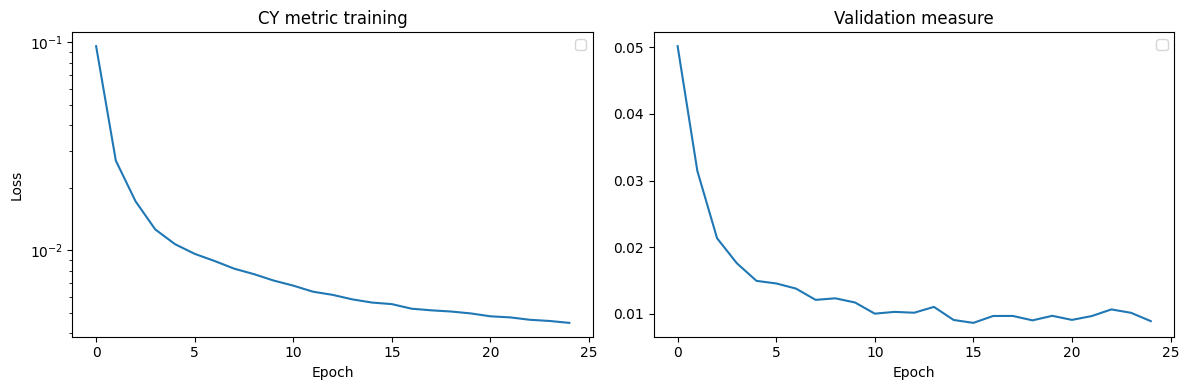

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = history['epochs']
axes[0].semilogy(epochs, history['General loss phase'])
#axes[0].semilogy(epochs, history['Volume loss phase'],  label='Volume phase')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='CY metric training')
axes[0].legend()
for k in ['sigma_val']:
    if k in history:
        axes[1].plot(epochs, history[k])
axes[1].set(xlabel='Epoch', title='Validation measure')
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
# --- Pre-compute HYM sources ρ_H and geometric weight matrices M ---
#
# ρ_H(L_a) = Σ_i k_a^i Tr(g_CY^{-1} g_ref^i_pb)       [eq. 3.3.65]
#
# g_ref^i_pb = J_i (κ_i I - x_i x_i†) J_i† / κ_i²   (3×3 complex)   [C7: bare ∂∂̄ ln κ, no 1/π]
# where J_i = J[:, 2i:2i+2]  (pullback restricted to i-th P^1 factor)
#
# M = J† g_CY^{-1} J   (8×8 complex)
# used during HYM training: Δβ = Tr(Ω_M Hess_β)   where Ω_M is built from M

@jax.jit
def compute_chunk(X_chunk):
    """Returns g_inv (B,3,3) complex, J (B,3,8) complex, x_c (B,8) complex."""
    g_cy  = metric_model(X_chunk)             # (B, 3, 3) complex
    J     = metric_model.pullbacks(X_chunk)   # (B, 3, 8) complex
    g_inv = jnp.linalg.inv(g_cy)             # (B, 3, 3) complex
    x_c   = (X_chunk[:, :8] + 1j * X_chunk[:, 8:]).astype(jnp.complex64)
    return g_inv, J, x_c

def gref_i_trace_with_ginv(g_inv, J, x_c, i):
    """Tr(g_inv @ g_ref^i_pb) batched over points.
    g_inv: (B,3,3), J: (B,3,8), x_c: (B,8)  – all complex
    Returns real (B,)
    """
    Ji   = J[:, :, 2*i:2*i+2]          # (B, 3, 2)
    xi   = x_c[:, 2*i:2*i+2]           # (B, 2)
    ki   = jnp.sum(jnp.abs(xi)**2, axis=1, keepdims=True)  # (B, 1)

    # g_ref_i_pb = [ ki * JiJi† - (Ji xi)(Ji xi)† ] / ki²   [C7: no 1/π]
    JiJi  = jnp.einsum('...ai,...bi->...ab', Ji, jnp.conj(Ji))      # (B,3,3)
    Jixi  = jnp.einsum('...ai,...i->...a', Ji, xi)                   # (B,3)
    outer = jnp.einsum('...a,...b->...ab', Jixi, jnp.conj(Jixi))    # (B,3,3)
    ki2   = (ki**2)[:, :, None]   # (B,1,1)
    ki_   = ki[:, :, None]        # (B,1,1)
    gref_i = (ki_ * JiJi - outer) / ki2                            # (B,3,3)  [C7: removed spurious 1/π]

    return jnp.real(jnp.trace(g_inv @ gref_i, axis1=-2, axis2=-1))  # (B,)

CHUNK = 512
n_train = X_train.shape[0]

# Pre-allocated arrays
hym_rho = {name: np.zeros(n_train, dtype=np.float32) for name in hym_names}
J_all     = np.zeros((n_train, 3, 8), dtype=np.complex64)
ginv_all  = np.zeros((n_train, 3, 3), dtype=np.complex64)

print("Pre-computing HYM sources (this may take a few minutes)...")
for start in tqdm(range(0, n_train, CHUNK)):
    end   = min(start + CHUNK, n_train)
    X_c   = jnp.array(X_train[start:end], dtype=jnp.float32)
    g_inv, J, x_c = compute_chunk(X_c)

    # Tr(g_inv @ g_ref^i_pb) for each P^1 factor
    traces = [gref_i_trace_with_ginv(g_inv, J, x_c, i) for i in range(4)]

    for name, k_vec in zip(hym_names, hym_charges):
        rho = sum(float(k_vec[i]) * np.array(traces[i]) for i in range(4))
        hym_rho[name][start:end] = rho.astype(np.float32)

    J_all[start:end]    = np.array(J)
    ginv_all[start:end] = np.array(g_inv)

w = y_train[:, 0].astype(np.float32)
print("Done.")
for name in hym_names:
    r = hym_rho[name]
    w_mean = float(np.sum(w * r) / np.sum(w))
    print(f"  ρ_H({name}): unweighted_mean={r.mean():.4f}  weighted_mean={w_mean:.4f}  (Fredholm: should be ≈0)  std={r.std():.4f}")

Pre-computing HYM sources (this may take a few minutes)...


100%|██████████| 879/879 [00:21<00:00, 40.26it/s]

Done.
  ρ_H(e2): unweighted_mean=-3.4161  weighted_mean=0.0389  (Fredholm: should be ≈0)  std=4.6023
  ρ_H(e5): unweighted_mean=3.4131  weighted_mean=-0.0433  (Fredholm: should be ≈0)  std=3.0013
  ρ_H(neg): unweighted_mean=0.0031  weighted_mean=0.0043  (Fredholm: should be ≈0)  std=2.8492



=== Training β_e2  (charges [-1. -3.  2.  2.]) ===
  Epoch  1/25: loss=2.195096  M_HYM=0.4925
  Epoch  2/25: loss=1.044098  M_HYM=0.2342
  Epoch  3/25: loss=0.792594  M_HYM=0.1778
  Epoch  4/25: loss=0.685763  M_HYM=0.1539
  Epoch  5/25: loss=0.638433  M_HYM=0.1432
  Epoch  6/25: loss=0.591337  M_HYM=0.1327
  Epoch  7/25: loss=0.562138  M_HYM=0.1261
  Epoch  8/25: loss=0.537446  M_HYM=0.1206
  Epoch  9/25: loss=0.513965  M_HYM=0.1153
  Epoch 10/25: loss=0.493712  M_HYM=0.1108
  Epoch 11/25: loss=0.478450  M_HYM=0.1073
  Epoch 12/25: loss=0.459018  M_HYM=0.1030
  Epoch 13/25: loss=0.441789  M_HYM=0.0991
  Epoch 14/25: loss=0.433330  M_HYM=0.0972
  Epoch 15/25: loss=0.422320  M_HYM=0.0947
  Epoch 16/25: loss=0.417924  M_HYM=0.0938
  Epoch 17/25: loss=0.408073  M_HYM=0.0916
  Epoch 18/25: loss=0.397771  M_HYM=0.0892
  Epoch 19/25: loss=0.390182  M_HYM=0.0875
  Epoch 20/25: loss=0.383641  M_HYM=0.0861
  Epoch 21/25: loss=0.377157  M_HYM=0.0846
  Epoch 22/25: loss=0.372202  M_HYM=0.0835
  

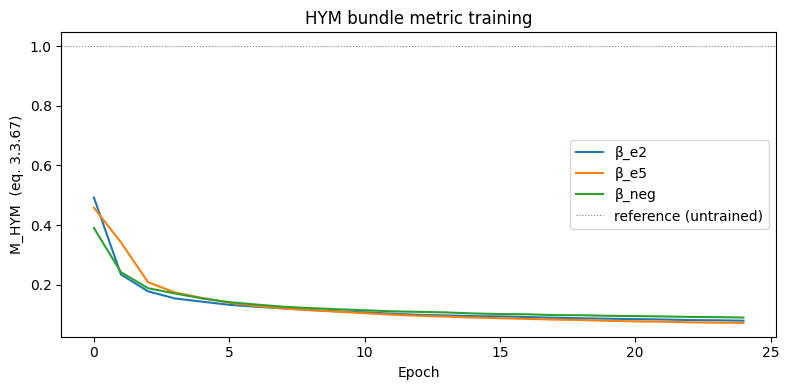

In [9]:
# --- HYM training ---
#
# Train β_a s.t. Δ_CY β_a = ρ_H(L_a)   [eq. 3.3.65]
# Loss (eq. 3.3.66):  L = Σ ŵ_i |Δβ(x_i) - ρ_H(x_i)|   (p=1, weighted)
# Validation measure (eq. 3.3.67): M_HYM = Σ ŵ_i|Δβ-ρ_H| / Σ ŵ_i|ρ_H|
#
# ŵ_i = y_train[:, 0]  (integration weights from the point generator,
#         correcting for the non-uniform sampling measure; dynamic range ~2877x)

def M_to_omega(M):
    """Convert 8×8 complex M to 16×16 real Ω for CY Laplacian."""
    R = jnp.real(M) / 4.
    I = jnp.imag(M) / 4.
    top = jnp.concatenate([R, -I], axis=1)
    bot = jnp.concatenate([I,  R], axis=1)
    return jnp.concatenate([top, bot], axis=0)

def cy_laplacian(scalar_fn, x, Omega):
    """Δ_CY f at x given pre-computed Ω.  Uses 16 HVPs via vmap."""
    grad_fn = jax.grad(scalar_fn)
    def hvp(col):
        return jax.jvp(grad_fn, (x,), (col,))[1]
    HO = jax.vmap(hvp, in_axes=1, out_axes=0)(Omega)
    return jnp.trace(HO)

def make_hym_nn(subkey):
    ks = jax.random.split(subkey, 5)
    return eqx.nn.Sequential([
        eqx.nn.Lambda(kappa_features),
        eqx.nn.Linear(16, 128, key=ks[1]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, 128, key=ks[2]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, 128, key=ks[3]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, 1, use_bias=False, key=ks[4]),
    ])

@eqx.filter_jit
def hym_step(model, X_b, J_b, ginv_b, rho_b, w_b, opt_state, optimizer):
    def loss_fn(model_):
        def per_point(x, J_i, ginv_i, rho_i):
            M     = jnp.conj(J_i).T @ ginv_i @ J_i
            Omega = M_to_omega(M)
            lap   = cy_laplacian(lambda z: model_(z)[0], x, Omega)
            return jnp.abs(lap - rho_i)
        pointwise = jax.vmap(per_point)(X_b, J_b, ginv_b, rho_b)
        return jnp.sum(w_b * pointwise) / jnp.sum(w_b)   # weighted mean

    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, opt_state_new = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    return eqx.apply_updates(model, updates), opt_state_new, loss

def train_hym(model, rho_all, n_epochs=25, batch_size=128, lr=1e-3):
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    hist      = []

    # Weighted reference loss: Σ ŵ_i |ρ_H(x_i)|  (eq. 3.3.67 denominator)
    w_all    = y_train[:, 0].astype(np.float32)
    ref_loss = float(np.sum(w_all * np.abs(rho_all)) / np.sum(w_all))

    for epoch in range(n_epochs):
        perm       = np.random.permutation(n_train)
        epoch_loss = 0.;  n_batches = 0
        for start in range(0, n_train, batch_size):
            idx   = perm[start:start + batch_size]
            X_b   = jnp.array(X_train[idx],  dtype=jnp.float32)
            J_b   = jnp.array(J_all[idx],    dtype=jnp.complex64)
            gi_b  = jnp.array(ginv_all[idx], dtype=jnp.complex64)
            rho_b = jnp.array(rho_all[idx],  dtype=jnp.float32)
            w_b   = jnp.array(w_all[idx],    dtype=jnp.float32)
            model, opt_state, loss = hym_step(
                model, X_b, J_b, gi_b, rho_b, w_b, opt_state, optimizer
            )
            epoch_loss += float(loss);  n_batches += 1
        mean_loss = epoch_loss / n_batches
        M_val = mean_loss / ref_loss
        hist.append(M_val)
        print(f"  Epoch {epoch+1:2d}/{n_epochs}: loss={mean_loss:.6f}  M_HYM={M_val:.4f}")
    return model, hist

# Train the three HYM networks
keys = jax.random.split(key, 4);  key = keys[0]
hym_models    = {}
hym_histories = {}

for name, k_vec, subkey in zip(hym_names, hym_charges, keys[1:4]):
    print(f"\n=== Training β_{name}  (charges {k_vec}) ===")
    nn = OrbitAvg(make_hym_nn(subkey))   # output-averaged -> Γ-invariant β
    nn, hist = train_hym(nn, hym_rho[name], n_epochs=25)
    hym_models[name]    = nn
    hym_histories[name] = hist

fig, ax = plt.subplots(figsize=(8, 4))
for name in hym_names:
    #ax.semilogy(hym_histories[name], label=f'β_{name}')
    ax.plot(hym_histories[name], label=f'β_{name}')
ax.set(xlabel='Epoch', ylabel='M_HYM  (eq. 3.3.67)', title='HYM bundle metric training')
ax.axhline(1.0, color='gray', lw=0.8, ls=':', label='reference (untrained)')
ax.legend()
plt.tight_layout()
plt.show()


Non-SUSY bundle charges: [1. 0. 0. 0.],  slope ∝ sum = 1
Computing ρ_H for non-SUSY bundle...


100%|██████████| 879/879 [00:02<00:00, 305.35it/s]


  ρ_H(non-SUSY): unweighted_mean=2.9249  weighted_mean=2.3327  (Fredholm: should be NON-zero)
  Compare SUSY:  weighted_mean≈0 (by construction)
  Epoch  1/25: loss=1.987588  M_HYM=0.8521
  Epoch  2/25: loss=1.158767  M_HYM=0.4968
  Epoch  3/25: loss=0.882862  M_HYM=0.3785
  Epoch  4/25: loss=0.773840  M_HYM=0.3317
  Epoch  5/25: loss=0.694659  M_HYM=0.2978
  Epoch  6/25: loss=0.638008  M_HYM=0.2735
  Epoch  7/25: loss=0.582828  M_HYM=0.2499
  Epoch  8/25: loss=0.546255  M_HYM=0.2342
  Epoch  9/25: loss=0.512766  M_HYM=0.2198
  Epoch 10/25: loss=0.491300  M_HYM=0.2106
  Epoch 11/25: loss=0.476221  M_HYM=0.2042
  Epoch 12/25: loss=0.459500  M_HYM=0.1970
  Epoch 13/25: loss=0.442392  M_HYM=0.1896
  Epoch 14/25: loss=0.432257  M_HYM=0.1853
  Epoch 15/25: loss=0.410303  M_HYM=0.1759
  Epoch 16/25: loss=0.393816  M_HYM=0.1688
  Epoch 17/25: loss=0.379779  M_HYM=0.1628
  Epoch 18/25: loss=0.366060  M_HYM=0.1569
  Epoch 19/25: loss=0.357615  M_HYM=0.1533
  Epoch 20/25: loss=0.341269  M_HYM=0.

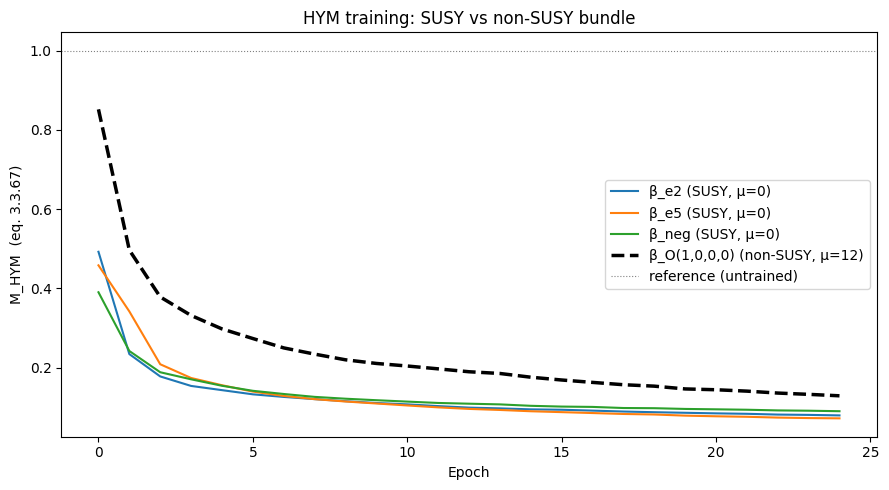


Non-SUSY Fredholm obstruction:
  weighted <ρ_H> = 2.3327  (100.0% of weighted ||ρ_H||_1)
  This sets a hard floor: M_HYM cannot drop below ≈1.000
  Final M_HYM (non-SUSY) = 0.1289  vs  SUSY = 0.0795


In [10]:
skip_non_susy = False 

# --- Non-SUSY HYM: training against an obstructed Poisson equation ---
#
# The SUSY condition for L = O(k_0,k_1,k_2,k_3) at the locus t_i=1 is:
#   μ(L) = d_{ijk} t^i t^j k^k = 12·Σ k_i = 0
# i.e. the charges must sum to zero.
#
# For a non-SUSY bundle (Σ k_i ≠ 0), the integral ∫ ρ_H ≠ 0 on the compact
# CY. By Stokes/Fredholm: ∫ Δβ = 0 for any β, so the equation Δβ = ρ_H
# is inconsistent — no solution exists. The network will fail to converge
# to zero loss, showing a qualitatively different training curve.
#
# We use L = O(1,0,0,0),  μ = 12·1 = 12  (maximally "non-SUSY" for unit charge).

if not skip_non_susy:

    k_nonsusy = np.array([1., 0., 0., 0.])
    print(f"Non-SUSY bundle charges: {k_nonsusy},  slope ∝ sum = {k_nonsusy.sum():.0f}")

    # Pre-compute ρ_H for the non-SUSY bundle (reuse J_all, ginv_all already stored)
    print("Computing ρ_H for non-SUSY bundle...")
    rho_nonsusy = np.zeros(n_train, dtype=np.float32)

    for start in tqdm(range(0, n_train, CHUNK)):
        end   = min(start + CHUNK, n_train)
        X_c   = jnp.array(X_train[start:end], dtype=jnp.float32)
        g_inv = jnp.array(ginv_all[start:end], dtype=jnp.complex64)
        J     = jnp.array(J_all[start:end],   dtype=jnp.complex64)
        x_c   = (X_c[:, :8] + 1j * X_c[:, 8:]).astype(jnp.complex64)
        traces = [gref_i_trace_with_ginv(g_inv, J, x_c, i) for i in range(4)]
        rho_nonsusy[start:end] = sum(float(k_nonsusy[i]) * np.array(traces[i]) for i in range(4))

    w_ns = y_train[:, 0].astype(np.float32)
    w_mean_ns = float(np.sum(w_ns * rho_nonsusy) / np.sum(w_ns))
    print(f"  ρ_H(non-SUSY): unweighted_mean={rho_nonsusy.mean():.4f}  weighted_mean={w_mean_ns:.4f}  (Fredholm: should be NON-zero)")
    print(f"  Compare SUSY:  weighted_mean≈0 (by construction)")

    # Train a non-SUSY HYM network — same setup as SUSY ones
    keys_ns = jax.random.split(key, 2)
    nn_nonsusy = make_hym_nn(keys_ns[1])

    nn_nonsusy, hist_nonsusy = train_hym(nn_nonsusy, rho_nonsusy, n_epochs=25)

    # Plot: SUSY vs non-SUSY training curves
    fig, ax = plt.subplots(figsize=(9, 5))
    for name in hym_names:
        #ax.semilogy(hym_histories[name], label=f'β_{name} (SUSY, μ=0)', lw=1.5)
        ax.plot(hym_histories[name], label=f'β_{name} (SUSY, μ=0)', lw=1.5)
    # hist_nonsusy already stores M values (train_hym normalises internally)
    M_nonsusy = hist_nonsusy
    #ax.semilogy(M_nonsusy, 'k--', lw=2.5, label=f'β_O(1,0,0,0) (non-SUSY, μ=12)')
    ax.plot(M_nonsusy, 'k--', lw=2.5, label=f'β_O(1,0,0,0) (non-SUSY, μ=12)')
    ax.axhline(1.0, color='gray', lw=0.8, ls=':', label='reference (untrained)')
    ax.set(xlabel='Epoch', ylabel='M_HYM  (eq. 3.3.67)', title='HYM training: SUSY vs non-SUSY bundle')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Quantify the obstruction using the weighted mean (the true Fredholm residual)
    w_ns = y_train[:, 0].astype(np.float32)
    w_mean_ns   = float(np.sum(w_ns * rho_nonsusy) / np.sum(w_ns))
    ref_nonsusy = float(np.sum(w_ns * np.abs(rho_nonsusy)) / np.sum(w_ns))   # weighted ||ρ_H||_1
    floor_frac  = abs(w_mean_ns) / ref_nonsusy
    print(f"\nNon-SUSY Fredholm obstruction:")
    print(f"  weighted <ρ_H> = {w_mean_ns:.4f}  ({100*floor_frac:.1f}% of weighted ||ρ_H||_1)")
    print(f"  This sets a hard floor: M_HYM cannot drop below ≈{floor_frac:.3f}")
    print(f"  Final M_HYM (non-SUSY) = {M_nonsusy[-1]:.4f}  vs  SUSY = {hym_histories['e2'][-1]:.4f}")


In [11]:
# --- Sigma-model (harmonic form) sources ---
#
# Seven networks σ satisfy Δ_L σ = ρ_ν   [eq. 3.3.69]
# ρ_ν = -H^{-1} g^{αβ̄} ∂_α(H ν_ref_{β̄})
#
# Type-I forms  (closed but not co-closed, eq. 6.1.34–6.1.36):
#   ν^H ,  ν^{U3} ,  ν^{Q3}
#
# Type-II forms (solve ∂̄ν_ref = source, eqs. 6.1.37–6.1.44):
#   ν^{U1}, ν^{U2}, ν^{Q1}, ν^{Q2}
#
# Bundle metrics entering each form (from eq. 6.1.33 and the line bundle
# structure in Section 8 of the MD):
#   ν^H           →  H_{-e2-e5} charges k_neg = ( 0, 2,-2, 0)   [C1]
#   ν^{Q3},ν^{U3} →  H_{e5}     charges k_e5  = ( 1, 1, 0,-2)
#   ν^{Q1},ν^{Q2} →  H_{e2}     charges k_e2  = (-1,-3, 2, 2)
#   ν^{U1},ν^{U2} →  H_{e2}     (same bundle)
#
# The bundle metric at a point: H_a(x) = ∏_i κ_i^{-k_a^i}  (eq. 6.1.9)

def bundle_metric(x_cplx, k_vec):
    """H_a(x) = ∏_i κ_i^{-k_a^i}.   x_cplx: (8,) complex, k_vec: (4,) real."""
    kappas = jnp.array([
        jnp.sum(jnp.abs(x_cplx[2*i:2*i+2])**2) for i in range(4)
    ])
    return jnp.prod(kappas ** (-jnp.array(k_vec)))

# The ρ_ν source requires the covariant divergence of the reference form.
# For a (0,1)-form ν_ref_{β̄}  the source is:
#
#   ρ_ν = -H^{-1} Σ_{α,β̄} g^{αβ̄} ∂_α(H ν_ref_{β̄})
#        = -Σ_{α,β̄} g^{αβ̄} [∂_α ln H · ν_ref_{β̄} + ∂_α ν_ref_{β̄}]
#
# In the pullback language everything lives in T_x X ≅ C^3.
# We express ν_ref as a C^3-valued function at each point (its components
# in the pullback basis), then compute ρ_ν by contracting with g^{-1}.
#
# For the Type-I reference forms, the ambient (0,1)-form is explicit.
# Its pull-back to a co-vector in C^3 is: (ν_ref_pb)_α = Σ_a ν_ref_a J̄_{α,a}
# (where J̄ is the conjugate pullback).
#
# We pre-compute ρ_ν at all training points using the trained CY metric
# and the HYM-corrected bundle metrics.

def log_H_grad_ambient(x_cplx, k_vec):
    """
    Wirtinger gradient ∂_a ln H_a (8-vector, complex).
    ∂/∂ξ^a ln H = -k_i  ∂/∂ξ^a ln κ_i  for the P^1_i containing coord a.
    ∂/∂ξ^{2i} ln κ_i = x̄_{i,0}/κ_i,   ∂/∂ξ^{2i+1} ln κ_i = x̄_{i,1}/κ_i.
    """
    grad = jnp.zeros(8, dtype=jnp.complex64)
    for i in range(4):
        xi    = x_cplx[2*i:2*i+2]
        kappa = jnp.sum(jnp.abs(xi)**2)
        d_lnk = jnp.conj(xi) / kappa   # (2,) Wirtinger ∂/∂ξ ln κ_i
        grad  = grad.at[2*i:2*i+2].set(-k_vec[i] * d_lnk)
    return grad  # (8,) complex

def pullback_form(nu_ambient, J):
    """
    Pull back ambient (0,1)-form ν_ambient (8-vector, complex) to CY
    co-vector in the pullback basis.
    Result: ν_pb_α = Σ_a ν_ambient_a J̄_{α,a}   (3-vector, complex)
    """
    return jnp.conj(J) @ nu_ambient   # (3,)

def rho_nu_from_form(nu_ambient, dnu_ambient_da, g_inv, J, x_cplx, k_vec):
    """
    Source ρ_ν = -Σ_{αβ̄} g^{αβ̄} [∂_α ln H · ν_ref_{β̄} + ∂_α ν_ref_{β̄}]

    nu_ambient:      (8,) complex – reference form components in ambient
    dnu_ambient_da:  (8, 8) complex – Jacobian: dnu_ambient_da[a,b] = ∂ν_a/∂ξ_b
                     (Wirtinger ∂/∂ξ^b of the a-th component of ν)
    g_inv:           (3,3) complex – inverse CY metric
    J:               (3,8) complex – pullback matrix
    x_cplx:          (8,) complex
    k_vec:           (4,) float – line bundle charges for this form
    """
    # ∂_α ln H = Σ_b (∂ ln H / ∂ξ^b) × (∂ξ^b/∂z^α) = J[α,:] · grad_lnH
    dlnH = log_H_grad_ambient(x_cplx, k_vec)  # (8,) complex Wirtinger grad
    dlnH_pb = J @ dlnH   # (3,) complex: ∂_α ln H in pullback basis

    # ν_ref pulled back: (ν_ref)_{β̄} in the J̄ basis
    nu_pb = pullback_form(nu_ambient, J)  # (3,) complex

    # ∂_α ν_ref_{β̄}: ambient Jacobian contracted with J on both sides
    # (∂_α ν_ref_{β̄}) = Σ_{a,b} J[α,b] ∂_b(ν_a) J̄[β̄,a]
    # But ν_{β̄} = Σ_a ν_a J̄[β̄,a], so ∂_α(ν_{β̄}) needs product rule.
    # Assuming J is constant along the CY (ambient embedding fixed):
    # ∂_α(ν_pb_{β̄}) = Σ_a (∂_α ν_a) J̄[β̄,a]
    #                = Σ_{a,b} J[α,b] (∂ν_a/∂ξ^b) J̄[β̄,a]
    #                = J @ dnu_da^T @ J̄^T  [view as matrix]
    dnu_pb = J @ dnu_ambient_da.T @ jnp.conj(J).T  # (3,3) complex: [α,β̄]

    # ρ_ν = -Tr(g^{-1} @ (dlnH_pb ⊗ nu_pb†  +  dnu_pb))
    term1 = jnp.outer(dlnH_pb, jnp.conj(nu_pb))  # (3,3)
    rho   = -jnp.trace(g_inv @ (term1 + dnu_pb))  # complex scalar
    return jnp.real(rho)  # should be real

print("Sigma-model source functions defined.")
print("Next: define the seven reference forms and pre-compute their sources.")

Sigma-model source functions defined.
Next: define the seven reference forms and pre-compute their sources.


In [12]:
# --- Reference forms (eqs. 6.1.34–6.1.44) ---
#
# All forms are expressed in the global (homogeneous) coordinate representation.
# At a point x, the ambient (0,1)-form components are ν_a = ν · dξ̄^a.
# The dξ̄^a form corresponds to differentiation w.r.t. ξ̄^a (conjugate coord).
#
# Storage: nu_ambient is (8,) complex, indexed as ξ̄^0,...,ξ̄^7 where
#   ξ^{2i} = x_{i+1,0},   ξ^{2i+1} = x_{i+1,1}  for i=0..3

def mu_bar(i, x_cplx):
    """
    Returns a unit of the basis (0,1)-form μ̄_i for the i-th P^1,
    as an 8-dim ambient co-vector indicating dξ̄^{2i} and dξ̄^{2i+1} contributions.
    We represent the P^1_i FS form (κ_i^{-1} times the FS volume form)
    as the pair of components in positions 2i, 2i+1.
    Normalise by κ_i as in the reference forms.
    """
    vec = jnp.zeros(8, dtype=jnp.complex64)
    xi  = x_cplx[2*i:2*i+2]
    ki  = jnp.sum(jnp.abs(xi)**2)
    # The (0,1)-form dξ̄^{2i} normalised by κ_i, as in the forms below
    return vec, ki, xi

# Type-I forms (harmonic on ambient, eqs. 6.1.34–6.1.36)
# We expand them as (0,1)-forms in the ξ̄^a basis.
# ν^H = κ_3^{-2} x_{2,0} x_{2,1} dξ̄^5  (using x_{3,j}↔ξ^{4+j}, and dξ̄^5 = dξ̄_{3,1})
# Wait – let me map coordinates carefully:
#   i=0: (x_{1,0}, x_{1,1}) = (ξ^0, ξ^1)
#   i=1: (x_{2,0}, x_{2,1}) = (ξ^2, ξ^3)
#   i=2: (x_{3,0}, x_{3,1}) = (ξ^4, ξ^5)
#   i=3: (x_{4,0}, x_{4,1}) = (ξ^6, ξ^7)
#
# eq. 6.1.34:  ν^H = κ_3^{-2} x_{2,0} x_{2,1} μ̄_3
#   μ̄_3 lives in the ξ̄^4, ξ̄^5 slots (i=2, i.e. the 3rd P^1)
#   κ_3 = |ξ^4|^2 + |ξ^5|^2
#   x_{2,0} = ξ^2,  x_{2,1} = ξ^3
#   ν^H_ambient: a (0,1)-form.  The μ̄_i form contributes to dξ̄^{2i}, dξ̄^{2i+1}.
#   [C2] μ̄_i = x̄_{i,0} dξ̄^{2i+1} - x̄_{i,1} dξ̄^{2i}  (CONJUGATED coords, NO 1/κ_i;
#   all κ powers sit in the form's prefactor). On x_{i,0}=1 it restricts to dz̄_i.
#   So ν^H_a(ξ^4) = κ_3^{-2} x_{2,0} x_{2,1} × κ_3^{-1} x_{3,1}  (coeff of dξ̄^4)
#      ν^H_a(ξ^5) = κ_3^{-2} x_{2,0} x_{2,1} × (-κ_3^{-1}) x_{3,0}

def nu_ref_typeI(x_cplx, form_name):
    """
    Type-I reference forms (eqs. 6.1.34–6.1.36).
    Returns (nu_ambient, k_vec) where nu_ambient is (8,) complex.

    Coordinates: ξ^{2i}, ξ^{2i+1} = x_{i+1,0}, x_{i+1,1}  for i=0..3.
    μ̄_i ≡  x̄_{i+1,0} dξ̄^{2i+1} - x̄_{i+1,1} dξ̄^{2i}   [C2: conjugated coords, NO 1/κ]
    """
    # Pre-compute kappas and coord aliases
    kappas = jnp.array([jnp.sum(jnp.abs(x_cplx[2*i:2*i+2])**2) for i in range(4)])

    def mu_bar_i(i):
        """Ambient (0,1)-form μ̄_i as an 8-vector (complex).  Normalised by 1/κ_i."""
        v = jnp.zeros(8, dtype=jnp.complex64)
        v = v.at[2*i  ].set(-jnp.conj(x_cplx[2*i+1]))    # [C2] coeff of dξ̄^{2i}   = -x̄_{i,1}
        v = v.at[2*i+1].set( jnp.conj(x_cplx[2*i]))      # [C2] coeff of dξ̄^{2i+1} = +x̄_{i,0}
        return v

    if form_name == 'H':
        # eq. 6.1.34: ν^H = κ_3^{-2} x_{2,0} x_{2,1} μ̄_3
        prefactor = x_cplx[2] * x_cplx[3] / kappas[2]**2  # κ_3^{-2} x_{2,0}x_{2,1}
        nu = prefactor * mu_bar_i(2)  # μ̄_3 (0-indexed i=2)
        k_vec = k_neg  # [C1] Higgs bundle L_{-e2-e5}

    elif form_name == 'U3':
        # eq. 6.1.35: ν^{U3} = κ_4^{-2} (x_{2,0}x_{1,1} - x_{2,1}x_{1,0}) μ̄_4
        prefactor = (x_cplx[2]*x_cplx[1] - x_cplx[3]*x_cplx[0]) / kappas[3]**2
        nu = prefactor * mu_bar_i(3)  # μ̄_4 (i=3)
        k_vec = k_e5   # L_5 bundle

    elif form_name == 'Q3':
        # eq. 6.1.36: ν^{Q3} = κ_4^{-2} (x_{2,0}x_{1,1} + x_{2,1}x_{1,0}) μ̄_4
        prefactor = (x_cplx[2]*x_cplx[1] + x_cplx[3]*x_cplx[0]) / kappas[3]**2
        nu = prefactor * mu_bar_i(3)  # μ̄_4 (i=3)
        k_vec = k_e5   # [C1] Q3 = Q_5 ∈ L_5

    else:
        raise ValueError(f"Unknown Type-I form: {form_name}")

    return nu, k_vec

def nu_ref_typeII(x_cplx, form_name):
    """
    Type-II reference forms (eqs. 6.1.37–6.1.44).
    These are NOT globally defined: they satisfy ∂̄ν = source  (non-closed).
    Here we construct them in the affine patch using eqs. 6.1.41–6.1.44.

    General form (eq. 6.1.44):  ν^{(II)}_ref = κ_1^{-2} κ_2^{-5} R̃ μ̄_2
    where R̃ = R̃(r_0, r_1, p_0, p_1, p_2) is defined by eq. 6.1.43,
    with (r_0, r_1) encoding the specific form via (6.1.41) and
    (p_0,p_1,p_2) = coefficients in x_{1,a} of the polynomial (6.1.42).

    Map: ξ^0=x_{1,0}, ξ^1=x_{1,1}, ξ^2=x_{2,0}, ξ^3=x_{2,1}
    """
    kappas = jnp.array([jnp.sum(jnp.abs(x_cplx[2*i:2*i+2])**2) for i in range(4)])
    k1, k2 = kappas[0], kappas[1]

    # x_1 = (x_{1,0}, x_{1,1}) = (ξ^0, ξ^1)
    # x_2 = (x_{2,0}, x_{2,1}) = (ξ^2, ξ^3)
    x10, x11 = x_cplx[0], x_cplx[1]
    x20, x21 = x_cplx[2], x_cplx[3]

    # Polynomial p decomposed in x_{1,a}  (eq. 6.1.42):
    # p = p_0(x_{i≠1}) x_{1,0}^2 + p_1 x_{1,0}x_{1,1} + p_2 x_{1,1}^2
    # For the TQ polynomial with psi0=2, psi1=1:
    #   p_0 = sum over (b,c,d) of [coeff × x2^b x3^c x4^d terms] × (x_{1,0})^2 piece
    # We compute p_0, p_1, p_2 by evaluating ∂^2 p / ∂ x_{1,0}^2 / 2, etc.
    # Easier: use the fact that:
    #   p_0 = (1/2) ∂^2 p / ∂ x_{1,0}^2
    #   p_1 = ∂^2 p / (∂ x_{1,0} ∂ x_{1,1})
    #   p_2 = (1/2) ∂^2 p / ∂ x_{1,1}^2
    # We'll compute these from the polynomial definition.

    # For the r vectors per form type (eq. 6.1.41): R = r_0 x̄_{1,0} + r_1 x̄_{1,1}
    # The four Type-II forms use:
    if form_name == 'U1':
        # U1: r_0 = x̄_{2,0}^3,  r_1 = x̄_{2,1}^3   (r0 fixed x21->x20: makes U1 a clean
        # Γ-eigenstate (-1,-1), matching the U-sector; was conj(x21)**3 which broke the symmetry)
        r0 = jnp.conj(x20)**3
        r1 = jnp.conj(x21)**3
        k_vec = k_e2   # [C1] U1 ∈ L_2
    elif form_name == 'U2':
        # eq. 6.1.38: r_0 = x̄_{2,1}^2 x̄_{2,0},  r_1 = x̄_{2,1} x̄_{2,0}^2
        r0 = jnp.conj(x21)**2 * jnp.conj(x20)
        r1 = jnp.conj(x21)    * jnp.conj(x20)**2
        k_vec = k_e2   # [C1] U2 ∈ L_2
    elif form_name == 'Q1':
        # eq. 6.1.39: r_0 = -x̄_{2,0}^3,  r_1 = x̄_{2,1}^3
        r0 = -jnp.conj(x20)**3
        r1 =  jnp.conj(x21)**3
        k_vec = k_e2
    elif form_name == 'Q2':
        # eq. 6.1.40: r_0 = -x̄_{2,1}^2 x̄_{2,0},  r_1 = x̄_{2,1} x̄_{2,0}^2
        r0 = -jnp.conj(x21)**2 * jnp.conj(x20)
        r1 =  jnp.conj(x21)    * jnp.conj(x20)**2
        k_vec = k_e2
    else:
        raise ValueError(f"Unknown Type-II form: {form_name}")

    # Compute p_0, p_1, p_2 (coefficients of x_{1,a}^2 terms in p)
    # Using the TQ polynomial structure (eqs. 6.1.18, cell 3 definition):
    # Fix x_{2,*}, x_{3,*}, x_{4,*} and extract the quadratic polynomial in x_{1,*}.
    # Evaluate at (x_{1,0}, x_{1,1}) = (1,0), (0,1), (1,1) to get p(1,0)=p_0,
    # p(0,1)=p_2, p(1,1)=p_0+p_1+p_2.
    def p_at_x1(a0, a1):
        """TQ polynomial with x_{1,*} replaced by (a0,a1)."""
        xs = jnp.array([a0, a1, x_cplx[2], x_cplx[3], x_cplx[4],
                         x_cplx[5], x_cplx[6], x_cplx[7]])
        X_ = jnp.array([xs[0], xs[1]])
        Y_ = jnp.array([xs[2], xs[3]])
        U_ = jnp.array([xs[4], xs[5]])
        V_ = jnp.array([xs[6], xs[7]])
        s = psi1 * (X_[0]*Y_[0]*U_[0]*V_[0]) * (X_[1]*Y_[1]*U_[1]*V_[1])
        for c in combinations:
            coeff = 1. if sum(c) % 2 == 0 else psi0
            s = s + coeff * (X_[c[0]] * Y_[c[1]] * U_[c[2]] * V_[c[3]])**2.
        return s

    p0_val  = p_at_x1(1.+0j, 0.+0j)   # p(x1=1, x2=0) = p_0
    p2_val  = p_at_x1(0.+0j, 1.+0j)   # p(x1=0, x2=1) = p_2
    p11_val = p_at_x1(1.+0j, 1.+0j)   # p(x1=1, x2=1) = p_0+p_1+p_2
    p0 = p0_val
    p2 = p2_val
    p1 = p11_val - p0 - p2

    # Calligraphic R (eq. 6.1.43)
    x1bar_0 = jnp.conj(x10);  x1bar_1 = jnp.conj(x11)
    R_cR = (
        -0.5*(p1*r0 + p2*r1) * jnp.abs(x10)**2 * x1bar_0
        + p0*r0 * jnp.abs(x10)**2 * x1bar_1
        + 0.5*p0*r1 * x10 * x1bar_1**2
        - 0.5*p2*r0 * x1bar_0**2 * x11
        - p2*r1 * x1bar_0 * jnp.abs(x11)**2
        + 0.5*(p0*r0 + p1*r1) * x1bar_1 * jnp.abs(x11)**2
    )

    # eq. 6.1.44: ν^{(II)} = κ_1^{-2} κ_2^{-5} R̃ μ̄_2
    prefactor = R_cR / (k1**2 * k2**5)
    # μ̄_2 in ambient 8-vec (i=1, i.e. x_{2,*} = ξ^2, ξ^3)
    mu2 = jnp.zeros(8, dtype=jnp.complex64)
    mu2 = mu2.at[2].set(-jnp.conj(x_cplx[3]))      # [C2] coeff of dξ̄^2 in μ̄_2  = -x̄_{2,1}
    mu2 = mu2.at[3].set( jnp.conj(x_cplx[2]))      # [C2] coeff of dξ̄^3 in μ̄_2  = +x̄_{2,0}
    nu = prefactor * mu2

    return nu, k_vec

print("Reference form functions defined.")

Reference form functions defined.


In [13]:
# --- Pre-compute sigma-model sources ρ_ν for all training points ---
#
# ρ_ν = -H^{-1} g^{αβ̄} ∂_α(H ν_ref_{β̄})
#      = -H^{-1} Tr(g^{-1}  J · d(H·ν)/dξ · conj(J)^T)
#
# Speedup: instead of calling jacfwd per point in a Python loop,
# define  f(x) = [Re(H·ν(x)), Im(H·ν(x))]  (16-dim real)
# and compute the full (B,16,16) Jacobian for the chunk in one call:
#     jax.vmap(jax.jacfwd(f))(X_chunk)
# then do a single batched einsum to contract with g^{-1} and pullbacks.

form_names_I   = ['H', 'U3', 'Q3']
form_names_II  = ['U1', 'U2', 'Q1', 'Q2']
all_form_names = form_names_I + form_names_II

# [G1] Use the HYM bundle metric H = e^β·H_ref (thesis 3.3.63/5.1.34) instead of H_ref.
#      Set USE_HYM_BUNDLE_METRIC=False to recover the reference-metric behaviour.
USE_HYM_BUNDLE_METRIC = True
form_bundle = {'H':'neg', 'Q1':'e2','Q2':'e2','Q3':'e5', 'U1':'e2','U2':'e2','U3':'e5'}

sigma_rho = {name: np.zeros(n_train, dtype=np.complex64) for name in all_form_names}  # COMPLEX: ρ_ν has a large imaginary part (see diagnostic); the real-σ ansatz discarded it

# --- f(x) = [Re(H·ν), Im(H·ν)]  for a single point, closed over form_name ---

def make_HNu_fn(form_name):
    """Returns a function x_real (16,) -> (16,) real for use with jacfwd."""
    def f(x_real):
        x_c = (x_real[:8] + 1j * x_real[8:]).astype(jnp.complex64)
        if form_name in form_names_I:
            nu, k_vec = nu_ref_typeI(x_c, form_name)
        else:
            nu, k_vec = nu_ref_typeII(x_c, form_name)
        kappas = jnp.array([jnp.sum(jnp.abs(x_c[2*i:2*i+2])**2) for i in range(4)])
        H   = jnp.prod(kappas ** (-jnp.array(k_vec)))
        if USE_HYM_BUNDLE_METRIC:                        # [G1] H = e^β · H_ref
            H = H * jnp.exp(hym_models[form_bundle[form_name]](x_real)[0])
        HNu = H * nu                                    # (8,) complex
        return jnp.concatenate([jnp.real(HNu), jnp.imag(HNu)])  # (16,) real
    return f

def make_H_fn(form_name):
    """Returns a function x_c (8,) complex -> scalar real."""
    def f(x_c):
        if form_name in form_names_I:
            _, k_vec = nu_ref_typeI(x_c, form_name)
        else:
            _, k_vec = nu_ref_typeII(x_c, form_name)
        kappas = jnp.array([jnp.sum(jnp.abs(x_c[2*i:2*i+2])**2) for i in range(4)])
        H = jnp.prod(kappas ** (-jnp.array(k_vec)))
        if USE_HYM_BUNDLE_METRIC:                        # [G1] H = e^β · H_ref
            x_real = jnp.concatenate([jnp.real(x_c), jnp.imag(x_c)])
            H = H * jnp.exp(hym_models[form_bundle[form_name]](x_real)[0])
        return H
    return f

# Pre-build and JIT one batched source function per form
def make_source_fn(form_name):
    HNu_fn = make_HNu_fn(form_name)
    H_fn   = make_H_fn(form_name)

    @jax.jit
    def source_batch(X_chunk, g_inv_chunk, J_chunk):
        x_c = (X_chunk[:, :8] + 1j * X_chunk[:, 8:]).astype(jnp.complex64)

        # (B, 16, 16) real Jacobian d[Re(H·ν), Im(H·ν)] / d[xR, xI]
        dHNu_dx = jax.vmap(jax.jacfwd(HNu_fn))(X_chunk)  # (B,16,16)

        # Wirtinger Jacobian d(H·ν_a)/dξ^b  (B,8,8) complex
        # ∂/∂ξ^b = (1/2)(∂/∂xR_b - i ∂/∂xI_b)
        # d(HNu_a)/dξ^b = (1/2)(d Re/d xR + d Im/d xI)
        #               + (i/2)(d Im/d xR - d Re/d xI)
        dHNu_wirt = (0.5*(dHNu_dx[:, :8, :8] + dHNu_dx[:, 8:, 8:])
                  + 0.5j*(dHNu_dx[:, 8:, :8] - dHNu_dx[:, :8, 8:])).astype(jnp.complex64)
        # dHNu_wirt[b, a, i] = ∂(H·ν_a)/∂ξ^i

        # T_{αβ̄} = J[α,b] d(HNu_a)/dξ^b conj(J[β̄,a])  → batched (B,3,3)
        # T[x,α,β̄] = Σ_{a,b} J[x,α,b] dHNu[x,a,b] conj(J[x,β̄,a])
        T = jnp.einsum('xαb, xab, xβa -> xαβ',
                       J_chunk, dHNu_wirt, jnp.conj(J_chunk))  # (B,3,3)

        H_vals = jax.vmap(H_fn)(x_c)    # (B,) real

        # ρ_ν = -H^{-1} Tr(g^{-1} T)   (complex — keep both parts; σ is now a complex section)
        return -jnp.trace(g_inv_chunk @ T, axis1=-2, axis2=-1) / H_vals  # (B,) complex

    return source_batch

source_fns = {name: make_source_fn(name) for name in all_form_names}

CHUNK_S = 512   # much larger now — fully vectorised over the batch
print("Pre-computing sigma-model sources (vectorised jacfwd)...")
for start in tqdm(range(0, n_train, CHUNK_S)):
    end  = min(start + CHUNK_S, n_train)
    X_c  = jnp.array(X_train[start:end], dtype=jnp.float32)
    gi_c = jnp.array(ginv_all[start:end], dtype=jnp.complex64)
    J_c  = jnp.array(J_all[start:end],   dtype=jnp.complex64)
    for name in all_form_names:
        sigma_rho[name][start:end] = np.array(source_fns[name](X_c, gi_c, J_c))

w = y_train[:, 0].astype(np.float32)
print("Done.")
for name in all_form_names:
    r = sigma_rho[name]
    w_mean = complex(np.sum(w * r) / np.sum(w))
    print(f"  rho_nu({name}): |mean|={np.abs(r.mean()):.4f}  weighted_mean={w_mean.real:+.4f}{w_mean.imag:+.4f}j  std(|.|)={np.abs(r).std():.4f}")


Pre-computing sigma-model sources (vectorised jacfwd)...


100%|██████████| 879/879 [01:29<00:00,  9.88it/s]

Done.
  rho_nu(H): |mean|=0.0011  weighted_mean=+0.0043+0.0007j  std(|.|)=0.3529
  rho_nu(U3): |mean|=0.0002  weighted_mean=-0.0057+0.0019j  std(|.|)=0.4748
  rho_nu(Q3): |mean|=0.0001  weighted_mean=-0.0048-0.0100j  std(|.|)=0.4749
  rho_nu(U1): |mean|=0.0291  weighted_mean=-0.0270-0.0093j  std(|.|)=0.7931
  rho_nu(U2): |mean|=0.0088  weighted_mean=+0.0620-0.0013j  std(|.|)=0.3639
  rho_nu(Q1): |mean|=0.0009  weighted_mean=-0.0028-0.0082j  std(|.|)=0.7928
  rho_nu(Q2): |mean|=0.0009  weighted_mean=-0.0082-0.0059j  std(|.|)=0.3632


In [14]:
# --- Diagnostic: how much of ρ_ν does jnp.real() discard? ---
# The real-σ ansatz (cell 13) + Re(ρ_ν) is only self-consistent if Im(tr(g⁻¹T))
# is negligible. The deprecated reference (laplacianWithH) keeps σ COMPLEX and
# matches the full complex equation. If the ratio below is not ≈0, the real-only
# ansatz is solving an under-determined Δ_L σ = ρ_ν and will bias the result.
def _complex_rho_batch(form_name, X_chunk, g_inv_chunk, J_chunk):
    HNu_fn = make_HNu_fn(form_name); H_fn = make_H_fn(form_name)
    x_c = (X_chunk[:, :8] + 1j * X_chunk[:, 8:]).astype(jnp.complex64)
    dHNu_dx = jax.vmap(jax.jacfwd(HNu_fn))(X_chunk)
    dHNu_wirt = (0.5*(dHNu_dx[:, :8, :8] + dHNu_dx[:, 8:, 8:])
              + 0.5j*(dHNu_dx[:, 8:, :8] - dHNu_dx[:, :8, 8:])).astype(jnp.complex64)
    T = jnp.einsum('xαb, xab, xβa -> xαβ', J_chunk, dHNu_wirt, jnp.conj(J_chunk))
    H_vals = jax.vmap(H_fn)(x_c)
    tr = jnp.trace(g_inv_chunk @ T, axis1=-2, axis2=-1)   # complex (before Re)
    return -tr / H_vals                                    # complex ρ_ν

_end = min(512, n_train)
_Xc  = jnp.array(X_train[:_end], dtype=jnp.float32)
_gic = jnp.array(ginv_all[:_end], dtype=jnp.complex64)
_Jc  = jnp.array(J_all[:_end],   dtype=jnp.complex64)
print("Im(ρ_ν) vs Re(ρ_ν)  (mean|Im| / mean|Re| over first chunk):")
for name in all_form_names:
    rc = np.array(_complex_rho_batch(name, _Xc, _gic, _Jc))
    ratio = np.mean(np.abs(rc.imag)) / (np.mean(np.abs(rc.real)) + 1e-12)
    flag = "  <-- non-negligible!" if ratio > 0.05 else ""
    print(f"  {name}: mean|Re|={np.abs(rc.real).mean():.4e}  mean|Im|={np.abs(rc.imag).mean():.4e}  ratio={ratio:.3f}{flag}")


Im(ρ_ν) vs Re(ρ_ν)  (mean|Im| / mean|Re| over first chunk):
  H: mean|Re|=3.9639e-01  mean|Im|=2.4230e-01  ratio=0.611  <-- non-negligible!
  U3: mean|Re|=4.1839e-01  mean|Im|=5.0720e-01  ratio=1.212  <-- non-negligible!
  Q3: mean|Re|=3.9853e-01  mean|Im|=4.4409e-01  ratio=1.114  <-- non-negligible!
  U1: mean|Re|=7.2790e-01  mean|Im|=5.5253e-01  ratio=0.759  <-- non-negligible!
  U2: mean|Re|=3.6620e-01  mean|Im|=2.9223e-01  ratio=0.798  <-- non-negligible!
  Q1: mean|Re|=7.1058e-01  mean|Im|=5.4817e-01  ratio=0.771  <-- non-negligible!
  Q2: mean|Re|=3.6982e-01  mean|Im|=3.0986e-01  ratio=0.838  <-- non-negligible!


  σ_H: bundle (0, 2, -2, 0), N_sections=9, NN outputs=18
  σ_Q1: bundle (-1, -3, 2, 2), N_sections=72, NN outputs=144
  σ_Q2: bundle (-1, -3, 2, 2), N_sections=72, NN outputs=144
  σ_Q3: bundle (1, 1, 0, -2), N_sections=12, NN outputs=24
  σ_U1: bundle (-1, -3, 2, 2), N_sections=72, NN outputs=144
  σ_U2: bundle (-1, -3, 2, 2), N_sections=72, NN outputs=144
  σ_U3: bundle (1, 1, 0, -2), N_sections=12, NN outputs=24

=== Training σ_H  (bundle (0, 2, -2, 0), N=9) ===
  Epoch  1/25: loss=0.226937  M_Δ=0.4084
  Epoch  2/25: loss=0.169143  M_Δ=0.3044
  Epoch  3/25: loss=0.138172  M_Δ=0.2487
  Epoch  4/25: loss=0.121664  M_Δ=0.2190
  Epoch  5/25: loss=0.112746  M_Δ=0.2029
  Epoch  6/25: loss=0.104867  M_Δ=0.1887
  Epoch  7/25: loss=0.098014  M_Δ=0.1764
  Epoch  8/25: loss=0.092887  M_Δ=0.1672
  Epoch  9/25: loss=0.089439  M_Δ=0.1610
  Epoch 10/25: loss=0.085578  M_Δ=0.1540
  Epoch 11/25: loss=0.082567  M_Δ=0.1486
  Epoch 12/25: loss=0.079987  M_Δ=0.1440
  Epoch 13/25: loss=0.077246  M_Δ=0.13

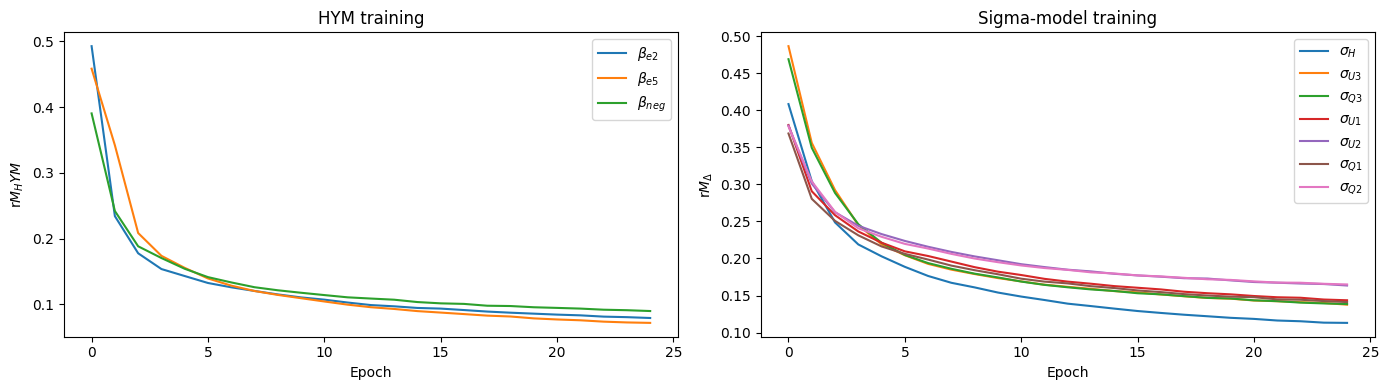

In [15]:
# --- Train sigma-model (harmonic form) networks ---
#
# σ is a section of L_a, so it must transform as ∏ λ_i^{k_i} σ under x_i → λ_i x_i.
# Parameterise as  σ(x) = Re( Σ_j c_j(x) s_j(x) )  (eq. 3.3.55)
#   c_j  – complex coefficients from an invariant (kappa-features) network
#   s_j  – fixed basis sections with the correct projective weight
#
# Section basis for L = O(k_0,k_1,k_2,k_3) — one factor per P^1_i:
#   k_i >= 0 : monomials  x_{i,0}^{k_i-a} x_{i,1}^a   for a=0..k_i
#   k_i <  0 : anti-monomials  x̄_{i,0}^{|k_i|-a} x̄_{i,1}^a / κ_i^{|k_i|}  for a=0..|k_i|
# Full basis = tensor product over the 4 factors;  N = ∏_i (|k_i|+1) sections.
#
# Network: same depth-4/width-128 invariant NN, but with 2N outputs
#   (real and imaginary parts of the N complex coefficients c_j).
#
# k_e2 = (-1,-3, 2, 2): N = 2×4×3×3 = 72  →  144 NN outputs
# k_e5 = ( 1, 1, 0,-2): N = 2×2×1×3 = 12  →   24 NN outputs

def build_sections(x_cplx, k_tuple):
    """
    Basis sections of L = O(k_tuple) at point x_cplx.
    k_tuple: tuple of 4 Python ints.
    Returns (N,) complex64  where N = ∏(|k_i|+1).
    """
    per_factor = []
    for i, ki in enumerate(k_tuple):
        xi     = x_cplx[2*i:2*i+2]   # (2,) complex
        abs_ki = abs(ki)
        if ki >= 0:
            segs = [xi[0]**(abs_ki - a) * xi[1]**a for a in range(abs_ki + 1)]
        else:
            kappa_i = jnp.sum(jnp.abs(xi)**2)
            segs = [jnp.conj(xi[0])**(abs_ki - a) * jnp.conj(xi[1])**a
                    / kappa_i**abs_ki for a in range(abs_ki + 1)]
        per_factor.append(jnp.stack(segs))
    result = per_factor[0]
    for s in per_factor[1:]:
        result = jnp.outer(result, s).reshape(-1)
    return result.astype(jnp.complex64)

def n_sections(k_tuple):
    n = 1
    for ki in k_tuple: n *= abs(ki) + 1
    return n

def make_sigma_nn(subkey, n_out):
    """Same invariant architecture, n_out = 2*N_sections (real+imag coefficients)."""
    ks = jax.random.split(subkey, 5)
    return eqx.nn.Sequential([
        eqx.nn.Lambda(kappa_features),
        eqx.nn.Linear(16, 128, key=ks[1]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, 128, key=ks[2]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, 128, key=ks[3]),
        eqx.nn.Lambda(jnn.gelu),
        eqx.nn.Linear(128, n_out, use_bias=False, key=ks[4]),
    ])

# --- Z2xZ2 orbit maps on the 16-real coords [xR(8), xI(8)] ---
_G1IDX  = jnp.array([1, 3, 5, 7, 9, 11, 13, 15])                 # x_{i,1} (real & imag)
_G2PERM = jnp.array([1,0,3,2,5,4,7,6, 9,8,11,10,13,12,15,14])    # swap x_{i,0} <-> x_{i,1}
def _g1(x): return x.at[_G1IDX].multiply(-1.0)   # g1: x_{i,1} -> -x_{i,1}
def _g2(x): return x[_G2PERM]                     # g2: x_{i,0} <-> x_{i,1}

def make_sigma_step(k_tuple, eps1, eps2, beta_model=None):
    """Factory: sigma_step closed over k_tuple and the target Γ=Z2xZ2 eigenvalues
    (eps1,eps2). σ is projected onto that irrep; the sources ρ_ν are Γ-symmetric, so
    the true σ lives in that irrep and the (otherwise Γ-breaking) network is forced into it."""
    N     = n_sections(k_tuple)
    k_jnp = jnp.array(k_tuple, dtype=jnp.float32)
    e1, e2 = jnp.float32(eps1), jnp.float32(eps2)

    def _raw(model_, x):
        x_c = (x[:8] + 1j * x[8:]).astype(jnp.complex64)
        s   = build_sections(x_c, k_tuple)
        out = model_(x)
        c   = out[:N] + 1j * out[N:]
        return jnp.dot(c, s)

    def sigma_cplx(model_, x):
        """COMPLEX section σ, PROJECTED onto the (eps1,eps2) Γ-irrep by averaging over
        the orbit {x, g1x, g2x, g1g2x} with signs (1, eps1, eps2, eps1*eps2).
        Imposes the discrete symmetry the network does not otherwise respect."""
        return 0.25 * ( _raw(model_, x)
                      + e1     * _raw(model_, _g1(x))
                      + e2     * _raw(model_, _g2(x))
                      + e1*e2  * _raw(model_, _g1(_g2(x))) )

    @eqx.filter_jit
    def step(model, X_b, J_b, ginv_b, rho_b, w_b, opt_state, optimizer):
        def loss_fn(model_):
            def per_point(x, J_i, ginv_i, rho_i):
                x_c   = (x[:8] + 1j * x[8:]).astype(jnp.complex64)
                M     = jnp.conj(J_i).T @ ginv_i @ J_i
                Omega = M_to_omega(M)

                # Raised bundle-connection vector  v_a = [J† g⁻¹ (J ∂_ξ lnH)]_a  (8,) complex
                dlnH_amb = log_H_grad_ambient(x_c, k_jnp)
                if beta_model is not None:               # [G1] ∂_ξ ln H = ∂_ξ ln H_ref + ∂_ξ β
                    gb = jax.grad(lambda z: beta_model(z)[0])(x)
                    dlnH_amb = dlnH_amb + 0.5 * (gb[:8] - 1j * gb[8:])
                v_corr   = jnp.conj(J_i).T @ (ginv_i @ (J_i @ dlnH_amb))

                # σ is complex → autodiff its real/imag parts separately, then recombine.
                def sR(z): return jnp.real(sigma_cplx(model_, z))
                def sI(z): return jnp.imag(sigma_cplx(model_, z))
                gR = jax.grad(sR)(x)   # (16,) real
                gI = jax.grad(sI)(x)   # (16,) real

                # ∂_ā σ  (ambient antiholo Wirtinger of the complex σ), (8,) complex
                dbar_sigma  = 0.5 * ((gR[:8] + 1j*gR[8:]) + 1j*(gI[:8] + 1j*gI[8:]))
                # first-order term g^{αβ̄}(∂_α lnH)(∂_β̄σ) — now the FULL complex value
                first_order = jnp.sum(v_corr * dbar_sigma)
                # Δ_CY σ = Δ_CY(Re σ) + i Δ_CY(Im σ)   (operator is C-linear in σ)
                lap_s       = cy_laplacian(sR, x, Omega) + 1j * cy_laplacian(sI, x, Omega)

                return jnp.abs(lap_s + first_order - rho_i)   # complex residual magnitude

            pw = jax.vmap(per_point)(X_b, J_b, ginv_b, rho_b)
            return jnp.sum(w_b * pw) / jnp.sum(w_b)

        loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
        updates, opt_state_new = optimizer.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        return eqx.apply_updates(model, updates), opt_state_new, loss

    return step

def train_sigma(model, rho_all, k_tuple, eps, beta_model=None, n_epochs=25, batch_size=128, lr=1e-3):
    sigma_step_fn = make_sigma_step(k_tuple, eps[0], eps[1], beta_model)
    optimizer     = optax.adam(lr)
    opt_state     = optimizer.init(eqx.filter(model, eqx.is_array))
    w_all         = y_train[:, 0].astype(np.float32)
    ref_loss      = float(np.sum(w_all * np.abs(rho_all)) / np.sum(w_all))
    hist          = []

    for epoch in range(n_epochs):
        perm       = np.random.permutation(n_train)
        epoch_loss = 0.;  n_batches = 0
        for start in range(0, n_train, batch_size):
            idx   = perm[start:start + batch_size]
            X_b   = jnp.array(X_train[idx],  dtype=jnp.float32)
            J_b   = jnp.array(J_all[idx],    dtype=jnp.complex64)
            gi_b  = jnp.array(ginv_all[idx], dtype=jnp.complex64)
            rho_b = jnp.array(rho_all[idx],  dtype=jnp.complex64)  # COMPLEX: ρ_ν has a large Im part (see cell-13 diagnostic)
            w_b   = jnp.array(w_all[idx],    dtype=jnp.float32)
            model, opt_state, loss = sigma_step_fn(
                model, X_b, J_b, gi_b, rho_b, w_b, opt_state, optimizer
            )
            epoch_loss += float(loss);  n_batches += 1
        mean_loss = epoch_loss / n_batches
        M_val = mean_loss / ref_loss
        hist.append(M_val)
        print(f"  Epoch {epoch+1:2d}/{n_epochs}: loss={mean_loss:.6f}  M_Δ={M_val:.4f}")
    return model, hist

# Form → line bundle charge map
form_charges = {                        # [C1] corrected to the physical spectrum (eq. 6.1.25):
    'H':  k_neg,                         #   H = H^u_{2,5}  ∈ L_{-e2-e5}
    'Q1': k_e2, 'Q2': k_e2, 'Q3': k_e5,  #   (Q^I) = (Q^1_2, Q^2_2, Q_5)
    'U1': k_e2, 'U2': k_e2, 'U3': k_e5,  #   (U^I) = (U^1_2, U^2_2, U_5)
}
# [C1/G1] consistency: form_charges must match the HYM bundle map form_bundle
_bk = {'e2': k_e2, 'e5': k_e5, 'neg': k_neg}
assert all(tuple(int(c) for c in form_charges[f]) == tuple(int(c) for c in _bk[form_bundle[f]])
           for f in all_form_names), 'form_charges vs form_bundle mismatch'

# Target Γ=Z2xZ2 eigenvalues (eps_g1, eps_g2) per σ — read off from the (symmetric) sources ρ_ν:
#   g1: +1 for all forms;  g2: -1 for the Q-sector (e2), +1 for the U-sector (e5).
form_eps = {
    'H':  (1, -1), 'Q3': (1, -1), 'Q1': (1, -1), 'Q2': (1, -1),
    'U3': (1,  1), 'U1': (1,  1), 'U2': (1,  1),
}

# Section counts: L_e2→72, L_e5→12
for name, kv in form_charges.items():
    kt = tuple(int(k) for k in kv)
    print(f"  σ_{name}: bundle {kt}, N_sections={n_sections(kt)}, NN outputs={2*n_sections(kt)}")

# Train all 7 sigma networks
keys = jax.random.split(key, 8);  key = keys[0]
sigma_models    = {}
sigma_histories = {}

for name, subkey in zip(all_form_names, keys[1:8]):
    k_tuple = tuple(int(k) for k in form_charges[name])
    N       = n_sections(k_tuple)
    print(f"\n=== Training σ_{name}  (bundle {k_tuple}, N={N}) ===")
    nn   = make_sigma_nn(subkey, 2 * N)
    nn, hist = train_sigma(nn, sigma_rho[name], k_tuple, form_eps[name],
                           beta_model=(hym_models[form_bundle[name]] if USE_HYM_BUNDLE_METRIC else None),
                           n_epochs=25)
    sigma_models[name]    = nn
    sigma_histories[name] = hist

# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in hym_names:
    #axes[0].semilogy(hym_histories[name], label=f'β_{name}')
    axes[0].plot(hym_histories[name], label=rf'$\beta_{{{name}}}$')
axes[0].set(xlabel='Epoch', ylabel='r$M_HYM$', title='HYM training')
#axes[0].axhline(1.0, color='gray', lw=0.8, ls=':')
axes[0].legend()
for name in all_form_names:
    #axes[1].semilogy(sigma_histories[name], label=f'σ_{name}')
    axes[1].plot(sigma_histories[name], label=rf'$\sigma_{{{name}}}$')
axes[1].set(xlabel='Epoch', ylabel='r$M_Δ$', title='Sigma-model training')
#axes[1].axhline(1.0, color='gray', lw=0.8, ls=':')
axes[1].legend()
plt.tight_layout()
plt.show()


In [16]:
# --- Save all trained networks and data ---
import datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
filename  = f'yukawa_run_{timestamp}.pkl'

# Convert equinox model leaves to numpy for portable pickling
def to_numpy(model):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(x) if hasattr(x, 'shape') else x, model
    )

# Load validation pullbacks from original dataset (needed for Yukawa integrals)
_data_full = np.load(os.path.join(dirname, 'dataset.npz'))
val_pullbacks = _data_full['val_pullbacks'] if 'val_pullbacks' in _data_full else None

save_data = {

    'metadata': {
        'timestamp'       : timestamp,
        'psi0'            : float(psi0),
        'psi1'            : float(psi1),
        'kmoduli'         : kmoduli.tolist(),
        'ambient'         : ambient.tolist(),
        'dirname'         : dirname,
        'n_train'         : int(n_train),
        'k_e2'            : k_e2.tolist(),
        'k_e5'            : k_e5.tolist(),
        'k_neg'           : k_neg.tolist(),
        'hym_names'       : hym_names,
        'form_names_I'    : form_names_I,
        'form_names_II'   : form_names_II,
        'all_form_names'  : all_form_names,
        'form_charges'    : {k: v.tolist() for k, v in form_charges.items()},
        'section_counts'  : {
            name: n_sections(tuple(int(k) for k in form_charges[name]))
            for name in all_form_names
        },
        'monomials'       : monomials.tolist(),
        'coefficients'    : coefficients.tolist(),
    },

    'models': {
        'metric_model'  : to_numpy(metric_model),
        'hym_models'    : {name: to_numpy(m) for name, m in hym_models.items()},
        'sigma_models'  : {name: to_numpy(m) for name, m in sigma_models.items()},
    },

    'training_data': {
        'X_train'       : np.asarray(X_train),
        'y_train'       : np.asarray(y_train),
        'X_val'         : np.asarray(X_val),
        'y_val'         : np.asarray(y_val),
        'val_pullbacks' : val_pullbacks,
    },

    'precomputed': {
        'J_all'         : np.asarray(J_all),
        'ginv_all'      : np.asarray(ginv_all),
        'hym_rho'       : {k: np.asarray(v) for k, v in hym_rho.items()},
        'sigma_rho'     : {k: np.asarray(v) for k, v in sigma_rho.items()},
    },

    'histories': {
        'hym_histories'   : hym_histories,
        'sigma_histories' : sigma_histories,
    },

    'BASIS_raw': BASIS_raw,
}

with open(filename, 'wb') as f:
    clean_data = dict(save_data)
    clean_data["models"] = dict(save_data["models"])
    clean_data["models"]["metric_model"] = eqx.tree_at(
        lambda m: m._sigma_loss_fn,
        clean_data["models"]["metric_model"],
        replace=[]
    )
    pickle.dump(clean_data, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(filename) / 1024**2
print(f"Saved: {filename}  ({size_mb:.1f} MB)")
print()
print("Contents:")
print(f"  Metric model   : PhiFSModel (depth 4, width 128, gelu)")
print(f"  HYM models     : {list(hym_models.keys())}")
print(f"  Sigma models   : {list(sigma_models.keys())}")
print(f"  Training pts   : X_train {X_train.shape}, y_train {y_train.shape}")
print(f"  Validation pts : X_val   {X_val.shape},   y_val   {y_val.shape}")
if val_pullbacks is not None:
    print(f"  Val pullbacks  : {val_pullbacks.shape} complex")
print(f"  Precomputed    : J_all {J_all.shape}, ginv_all {ginv_all.shape}")
print(f"  HYM sources    : {list(hym_rho.keys())}")
print(f"  Sigma sources  : {list(sigma_rho.keys())}")
print(f"  Section counts : { {n: n_sections(tuple(int(k) for k in form_charges[n])) for n in all_form_names} }")


Saved: yukawa_run_20260617_223838.pkl  (231.3 MB)

Contents:
  Metric model   : PhiFSModel (depth 4, width 128, gelu)
  HYM models     : ['e2', 'e5', 'neg']
  Sigma models   : ['H', 'U3', 'Q3', 'U1', 'U2', 'Q1', 'Q2']
  Training pts   : X_train (450000, 16), y_train (450000, 2)
  Validation pts : X_val   (50000, 16),   y_val   (50000, 2)
  Val pullbacks  : (50000, 3, 8) complex
  Precomputed    : J_all (450000, 3, 8), ginv_all (450000, 3, 3)
  HYM sources    : ['e2', 'e5', 'neg']
  Sigma sources  : ['H', 'U3', 'Q3', 'U1', 'U2', 'Q1', 'Q2']
  Section counts : {'H': 9, 'U3': 12, 'Q3': 12, 'U1': 72, 'U2': 72, 'Q1': 72, 'Q2': 72}


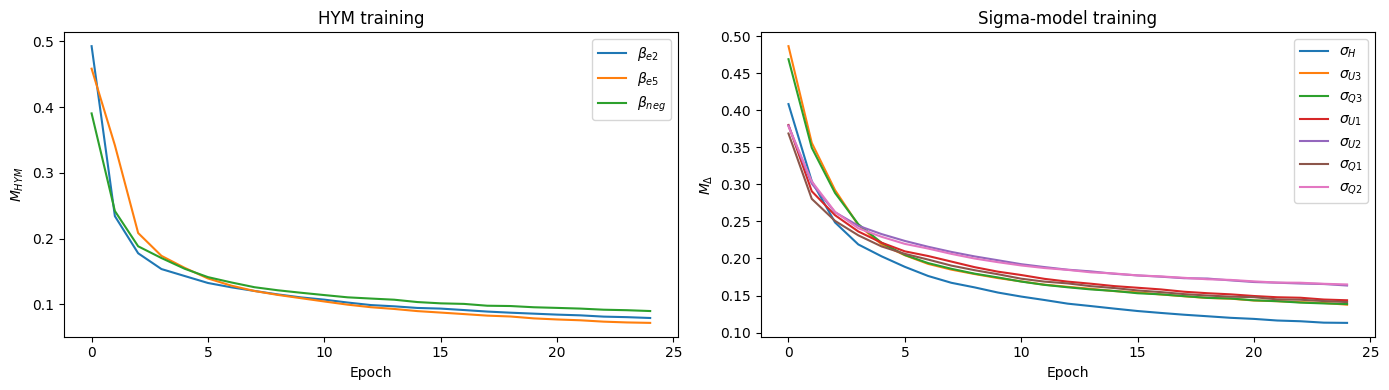

In [17]:
# Summary plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in hym_names:
    #axes[0].semilogy(hym_histories[name], label=f'β_{name}')
    axes[0].plot(hym_histories[name], label=rf'$\beta_{{{name}}}$')
axes[0].set(xlabel='Epoch', ylabel='$M_{HYM}$', title='HYM training')
#axes[0].axhline(1.0, color='gray', lw=0.8, ls=':')
axes[0].legend()
for name in all_form_names:
    #axes[1].semilogy(sigma_histories[name], label=f'σ_{name}')
    axes[1].plot(sigma_histories[name], label=rf'$\sigma_{{{name}}}$')
axes[1].set(xlabel='Epoch', ylabel='$M_Δ$', title='Sigma-model training')
#axes[1].axhline(1.0, color='gray', lw=0.8, ls=':')
axes[1].legend()
plt.tight_layout()
plt.show()